# Weak-lensing galaxy shape catalogue validation 1

## Cosmology results

Contents
- Shear-shear correlation function
- Cluster lensing
- Convergence maps

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [107]:
import os

In [108]:
from sp_validation.util import *
from sp_validation.cat import *

#sp_base = f"{os.environ['HOME']}/astro/repositories/github/sp_validation"
#
## The following commands will be replaced by import instructions, once the sp_validation scripts are stable
#for sc in ['util', 'cosmology', 'plots', 'plot_style']:
#    script = os.path.join(sp_base, 'sp_validation', sc)
#    %run $script

### Shear-shear correlation function

In [109]:
#### ngmix

In [111]:
ra = ra_ngmix
dec = dec_ngmix
e1 = g_corr_mc_ngmix[0]
e2 = g_corr_mc_ngmix[1]
weights = w_ngmix

res_g_ngmix = xi_gal_gal_tc(ra, dec, e1, e2, weights, ra, dec, e1, e2, weights)

In [113]:
sp_base= f'{os.environ["HOME"]}/sp_validation'
script = os.path.join(sp_base, 'sp_validation', 'cosmology.py')
%run $script

Could not import clmm.modeling, continuing...


In [114]:
xi_p_planck, xi_m_planck = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

/home/mkilbing/.conda/envs/shapepipe/lib/python3.7/site-packages/pyccl/correlation.py:83: CCLWarning: corr_type is deprecated. Use type = GG+
  CCLWarning)
/home/mkilbing/.conda/envs/shapepipe/lib/python3.7/site-packages/pyccl/correlation.py:83: CCLWarning: corr_type is deprecated. Use type = GG-
  CCLWarning)


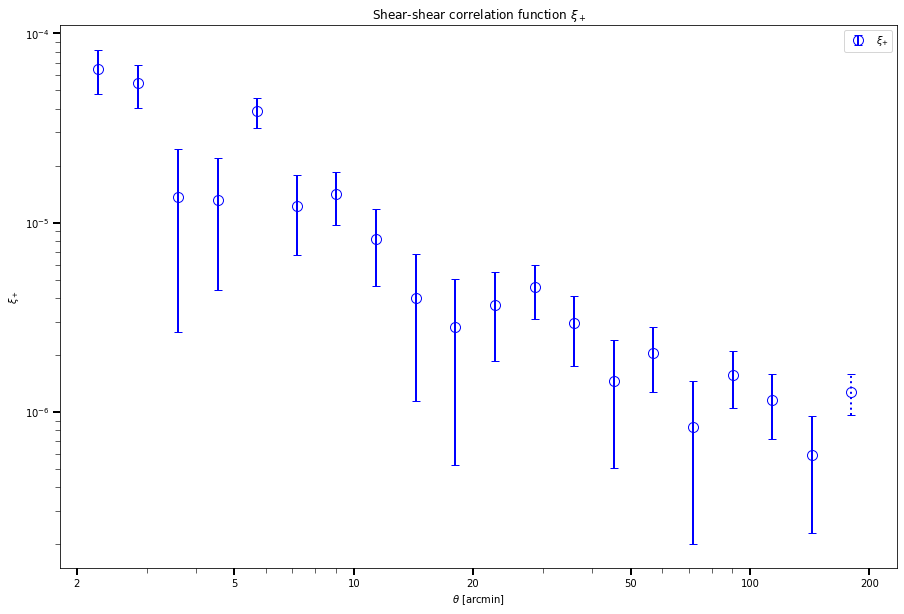

In [115]:
pos_ind_gg = res_g_ngmix.xip >= 0
neg_ind_gg = res_g_ngmix.xip < 0

x = [res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.meanr[neg_ind_gg]]
y = [res_g_ngmix.xip[pos_ind_gg], -res_g_ngmix.xip[neg_ind_gg]]
yerr = [np.sqrt(res_g_ngmix.varxip[pos_ind_gg]), np.sqrt(res_g_ngmix.varxip[neg_ind_gg])]
labels = [r'$\xi_{+}$', '']
linestyles = ['', '']
eb_linestyles = ['-', ':']
colors = ['b', 'b']
title = r'Shear-shear correlation function $\xi_+$'
xlabel = r'$\theta$ [arcmin]'
ylabel = r'$\xi_+$'

out_path = f'{plot_dir}/xi_+_shear_shear_ngmix.pdf'
xlog = True
ylog = True

plot_data_1d(x, y, yerr, title, xlabel, ylabel, out_path, xlog=xlog, ylog=ylog, labels=labels,
             colors=colors, linestyles=linestyles, eb_linestyles=eb_linestyles)

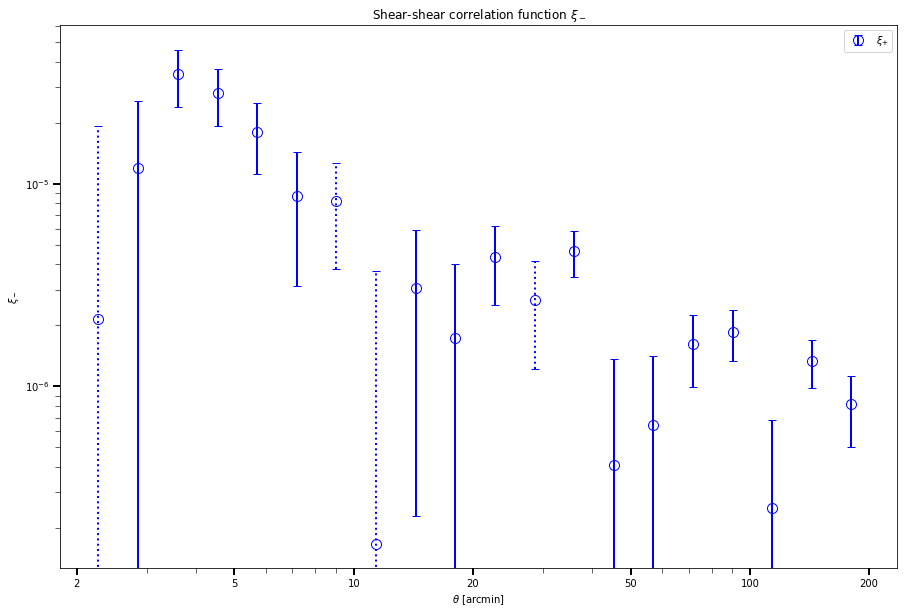

In [116]:
pos_ind_gg = res_g_ngmix.xim >= 0
neg_ind_gg = res_g_ngmix.xim < 0

x = [res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.meanr[neg_ind_gg]]
y = [res_g_ngmix.xim[pos_ind_gg], -res_g_ngmix.xim[neg_ind_gg]]
yerr = [np.sqrt(res_g_ngmix.varxim[pos_ind_gg]), np.sqrt(res_g_ngmix.varxim[neg_ind_gg])]
labels = [r'$\xi_{+}$', '']
linestyles = ['', '']
eb_linestyles = ['-', ':']
colors = ['b', 'b']
title = 'Shear-shear correlation function $\\xi_-$'
ylabel = r'$\xi_-$'

out_path = f'{plot_dir}/xi_-_shear_shear_ngmix.pdf'
xlog = True
ylog = True

plot_data_1d(x, y, yerr, title, xlabel, ylabel, out_path, xlog=xlog, ylog=ylog, labels=labels,
             colors=colors, linestyles=linestyles, eb_linestyles=eb_linestyles)

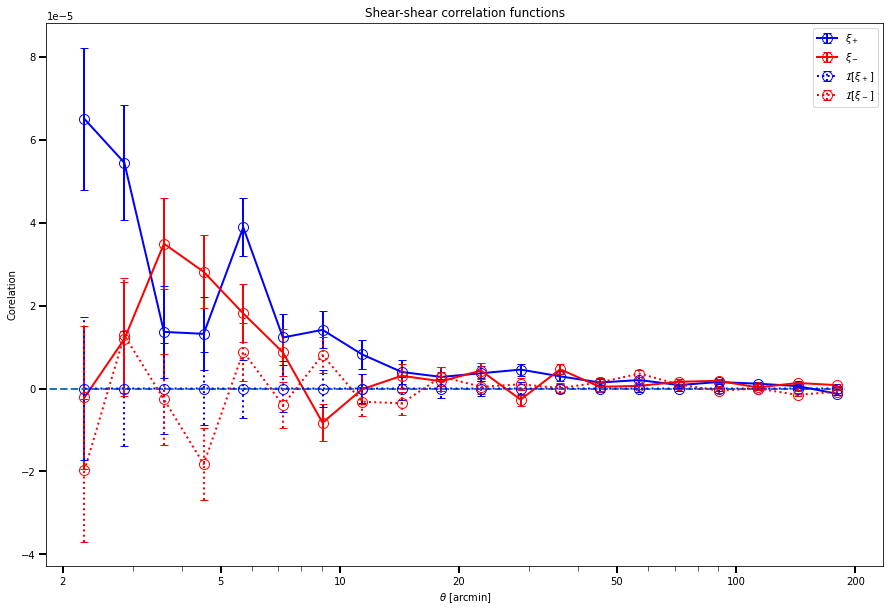

In [117]:
x = [res_g_ngmix.meanr] * 4
y = [res_g_ngmix.xip, res_g_ngmix.xim, res_g_ngmix.xip_im, res_g_ngmix.xim_im]
yerr = [np.sqrt(res_g_ngmix.varxip), np.sqrt(res_g_ngmix.varxim)] * 2
labels = [r'$\xi_+$', r'$\xi_-$', r'${\cal I}[\xi_+]$', r'${\cal I}[\xi_-]$']
linestyles = ['-', '-', ':', ':']
eb_linestyles = ['-', '-', ':', ':']
colors = ['b', 'r', 'b', 'r']
title = 'Shear-shear correlation functions'
ylabel = r'Corelation'

out_path = f'{plot_dir}/xi_pm_reim_shear_shear_ngmix.pdf'
xlog = True
ylog = False

plot_data_1d(x, y, yerr, title, xlabel, ylabel, out_path, xlog=xlog, ylog=ylog, labels=labels,
             colors=colors, linestyles=linestyles, eb_linestyles=eb_linestyles)

### Cluster lensing

#### Prepare Planck cluster catalog

In [161]:
cluster_cat_name = 'HFI_PCCS_SZ-union_R2.08.fits.gz'
vos_dir = 'vos:cfis/cosmostat/cosmology/external/Planck'

clusters = get_clusters(cluster_cat_name, vos_dir, name)

print_stats(f"{len(clusters['ra'])} clusters found in {name} footprint", stats_file, verbose=verbose)

NameError: name 'get_clusters' is not defined

In [119]:

print_stats(f"{len(cluster_cut['ra'])} clusters found in {name} footprint", stats_file, verbose=verbose)

4 clusters found in W3 footprint


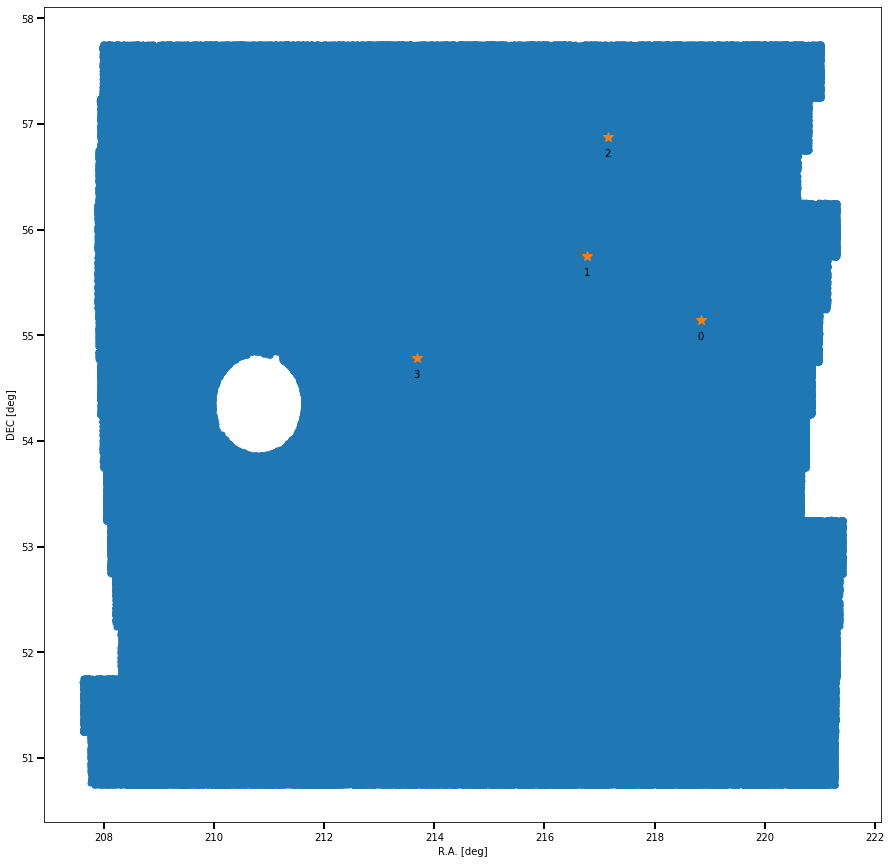

In [120]:
x_gal = ra_ngmix
y_gal = dec_ngmix
x_cluster = cluster_cut['ra']
y_cluster = cluster_cut['dec']

plt.figure(figsize=(15,15))
plt.plot(x_gal, y_gal, '.')
plt.plot(x_cluster, y_cluster, '*')

plt.xlabel('R.A. [deg]')
plt.ylabel('DEC [deg]')

dy = 0.02 * (plt.ylim()[0] - plt.ylim()[1])
for i in range(len(x_cluster)):
    x = x_cluster[i]
    y = y_cluster[i] + dy
    plt.text(x, y, i, color='k', fontsize=10, ha='center', va='center')

In [121]:
# TODO: Identify clusters within unmasked footprint.

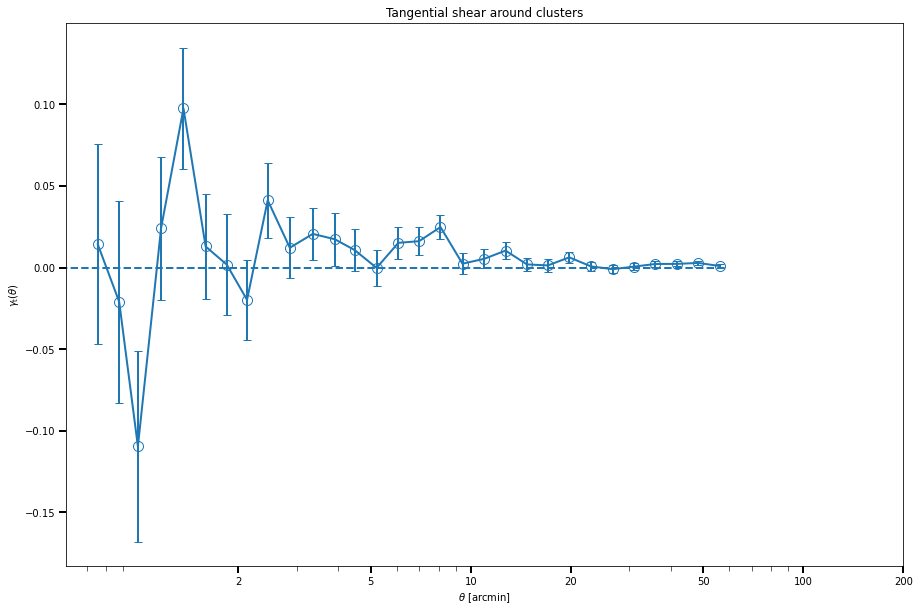

In [122]:
e1 = g_corr_mc_ngmix[0]
e2 = g_corr_mc_ngmix[1]

R_p, logR_p, gamT_p, gamX_p, gam_sig_p = gamma_T_tc(
    x_cluster,
    y_cluster,
    x_gal,
    y_gal,
    e1,
    e2,
    w_ngmix
)

x = [R_p]
y = [gamT_p]
yerr = [gam_sig_p]
title = 'Tangential shear around clusters'
ylabel = r'$\gamma_{\rm t}(\theta)$'
out_path = f'{plot_dir}/gamma_t_clusters.pdf'

plot_data_1d(x, y, yerr, title, xlabel, ylabel, out_path, xlog=True, ylog=False)